### **Cell 1: Instalasi & Import Library**

In [14]:
!pip install mlflow
!pip install stable_baselines3

In [15]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import gymnasium as gym
from gymnasium import spaces
import mlflow
import mlflow.sklearn

In [16]:
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.monitor import Monitor

warnings.filterwarnings("ignore")
np.random.seed(42)

print("✅ Semua library berhasil diimport.")
print(f"   - Gymnasium  : {gym.__version__}")
print(f"   - MLflow     : {mlflow.__version__}")

✅ Semua library berhasil diimport.
   - Gymnasium  : 1.2.3
   - MLflow     : 3.11.1


# **Cell 2: Konfigurasi Global**

In [17]:
DATA_FILE = "Dataset_BBCA.JK_2020-01-01_hingga_Hari_Ini.csv"
TRAIN_RATIO = 0.80


RSI_PERIOD      = 14
EMA_SHORT       = 20
EMA_LONG        = 50
FIBO_LOOKBACK   = 60

INITIAL_BALANCE = 100_000_000
TRANSACTION_FEE = 0.001
LOT_SIZE        = 100
N_LOTS          = 10

PPO_PARAMS = {
    "learning_rate"  : 3e-4,
    "n_steps"        : 2048,
    "batch_size"     : 64,
    "n_epochs"       : 10,
    "gamma"          : 0.99,
    "gae_lambda"     : 0.95,
    "clip_range"     : 0.2,
    "ent_coef"       : 0.01,
    "verbose"        : 0,
}
TOTAL_TIMESTEPS  = 200_000
MODEL_SAVE_PATH  = "ppo_bbca_model"


MLFLOW_EXPERIMENT = "PPO_Trading_BBCA"

print("✅ Konfigurasi global berhasil dimuat.")
print(f"   Modal Awal     : Rp {INITIAL_BALANCE:,.0f}")
print(f"   Rasio Train    : {TRAIN_RATIO*100:.0f}% / {(1-TRAIN_RATIO)*100:.0f}%")
print(f"   Total Timesteps: {TOTAL_TIMESTEPS:,}")

✅ Konfigurasi global berhasil dimuat.
   Modal Awal     : Rp 100,000,000
   Rasio Train    : 80% / 20%
   Total Timesteps: 200,000


# **Cell 3: Fungsi Data Preprocessing & Feature Engineering**

In [18]:
def load_and_clean_data(filepath: str) -> pd.DataFrame:
    """
    Memuat dan membersihkan dataset saham dari file CSV.
    - Parsing kolom Date sebagai index
    - Memastikan tipe data numerik untuk OHLCV
    - Menghapus baris dengan nilai kosong
    """
    print(f" Memuat data dari: {filepath}")
    df = pd.read_csv(filepath, parse_dates=["Date"], index_col="Date")
    df.sort_index(inplace=True)

    for col in ["Open", "High", "Low", "Close", "Volume"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df.dropna(inplace=True)
    print(f"   Data shape setelah cleaning: {df.shape}")
    print(f"   Rentang tanggal: {df.index.min().date()} s/d {df.index.max().date()}")
    return df


def compute_rsi(series: pd.Series, period: int = 14) -> pd.Series:
    """
    Menghitung Relative Strength Index (RSI).
    Formula: RSI = 100 - (100 / (1 + RS))
    RS = Rata-rata Gain / Rata-rata Loss dalam periode N hari
    """
    delta = series.diff()
    gain  = delta.clip(lower=0)
    loss  = -delta.clip(upper=0)

    avg_gain = gain.ewm(com=period - 1, min_periods=period).mean()
    avg_loss = loss.ewm(com=period - 1, min_periods=period).mean()

    rs  = avg_gain / (avg_loss + 1e-9)
    rsi = 100 - (100 / (1 + rs))
    return rsi


def compute_ema(series: pd.Series, span: int) -> pd.Series:
    """
    Menghitung Exponential Moving Average (EMA).
    EMA memberikan bobot lebih besar pada harga terbaru.
    """
    return series.ewm(span=span, adjust=False).mean()


def compute_fibonacci_levels(df: pd.DataFrame, lookback: int = 60) -> pd.DataFrame:
    """
    Menghitung level Fibonacci Retracement menggunakan rolling window.
    Level yang dihitung: 0%, 23.6%, 38.2%, 50%, 61.8%, 100%
    PENTING: Menggunakan .shift(1) untuk menghindari data leakage —
    harga hari ini tidak boleh digunakan untuk menghitung sinyal hari ini.
    """
    rolling_high = df["High"].rolling(window=lookback).max().shift(1)
    rolling_low  = df["Low"].rolling(window=lookback).min().shift(1)
    diff         = rolling_high - rolling_low

    df["fibo_0"]    = rolling_low
    df["fibo_236"]  = rolling_low + 0.236 * diff
    df["fibo_382"]  = rolling_low + 0.382 * diff
    df["fibo_500"]  = rolling_low + 0.500 * diff
    df["fibo_618"]  = rolling_low + 0.618 * diff
    df["fibo_100"]  = rolling_high
    return df


def feature_engineering(df: pd.DataFrame) -> pd.DataFrame:
    """
    Pipeline Feature Engineering yang terstruktur.
    Semua indikator dihitung hanya dari data historis (tidak ada look-ahead bias).
    """
    print("\n🔧 Menjalankan Feature Engineering Pipeline...")

    df["rsi"] = compute_rsi(df["Close"], period=RSI_PERIOD)
    df["ema_short"] = compute_ema(df["Close"], span=EMA_SHORT)
    df["ema_long"]  = compute_ema(df["Close"], span=EMA_LONG)
    df = compute_fibonacci_levels(df, lookback=FIBO_LOOKBACK)
    df["daily_return"]  = df["Close"].pct_change().shift(1)   # shift: anti-leakage
    df["volatility"]    = df["daily_return"].rolling(14).std().shift(1)
    df["vol_normalized"]= (df["Volume"] / df["Volume"].rolling(20).mean()).shift(1)
    df.dropna(inplace=True)
    print(f"   Shape setelah feature engineering: {df.shape}")
    print(f"   Fitur yang tersedia: {list(df.columns)}")
    return df


def train_test_split_timeseries(df: pd.DataFrame, train_ratio: float = 0.8):
    """
    Membagi data secara kronologis untuk time-series.
    PENTING: Tidak boleh menggunakan random split pada data time-series
    karena akan menyebabkan data leakage temporal.
    """
    split_idx      = int(len(df) * train_ratio)
    df_train       = df.iloc[:split_idx].copy()
    df_test        = df.iloc[split_idx:].copy()

    print(f"\n  Train-Test Split (Kronologis):")
    print(f"   Train: {len(df_train)} baris | {df_train.index.min().date()} → {df_train.index.max().date()}")
    print(f"   Test : {len(df_test)} baris  | {df_test.index.min().date()} → {df_test.index.max().date()}")
    return df_train, df_test

# **Cell 4: Eksekusi Preprocessing**

In [19]:
df_raw          = load_and_clean_data(DATA_FILE)
df_featured     = feature_engineering(df_raw)
df_train, df_test = train_test_split_timeseries(df_featured, TRAIN_RATIO)

print("\n✅ Preprocessing selesai.")

 Memuat data dari: Dataset_BBCA.JK_2020-01-01_hingga_Hari_Ini.csv
   Data shape setelah cleaning: (1521, 5)
   Rentang tanggal: 2020-01-02 s/d 2026-04-28

🔧 Menjalankan Feature Engineering Pipeline...
   Shape setelah feature engineering: (1461, 17)
   Fitur yang tersedia: ['Open', 'High', 'Low', 'Close', 'Volume', 'rsi', 'ema_short', 'ema_long', 'fibo_0', 'fibo_236', 'fibo_382', 'fibo_500', 'fibo_618', 'fibo_100', 'daily_return', 'volatility', 'vol_normalized']

✂️  Train-Test Split (Kronologis):
   Train: 1168 baris | 2020-03-27 → 2025-01-24
   Test : 293 baris  | 2025-01-30 → 2026-04-28

✅ Preprocessing selesai.


# **Cell 5: Visualisasi Indikator Teknikal**

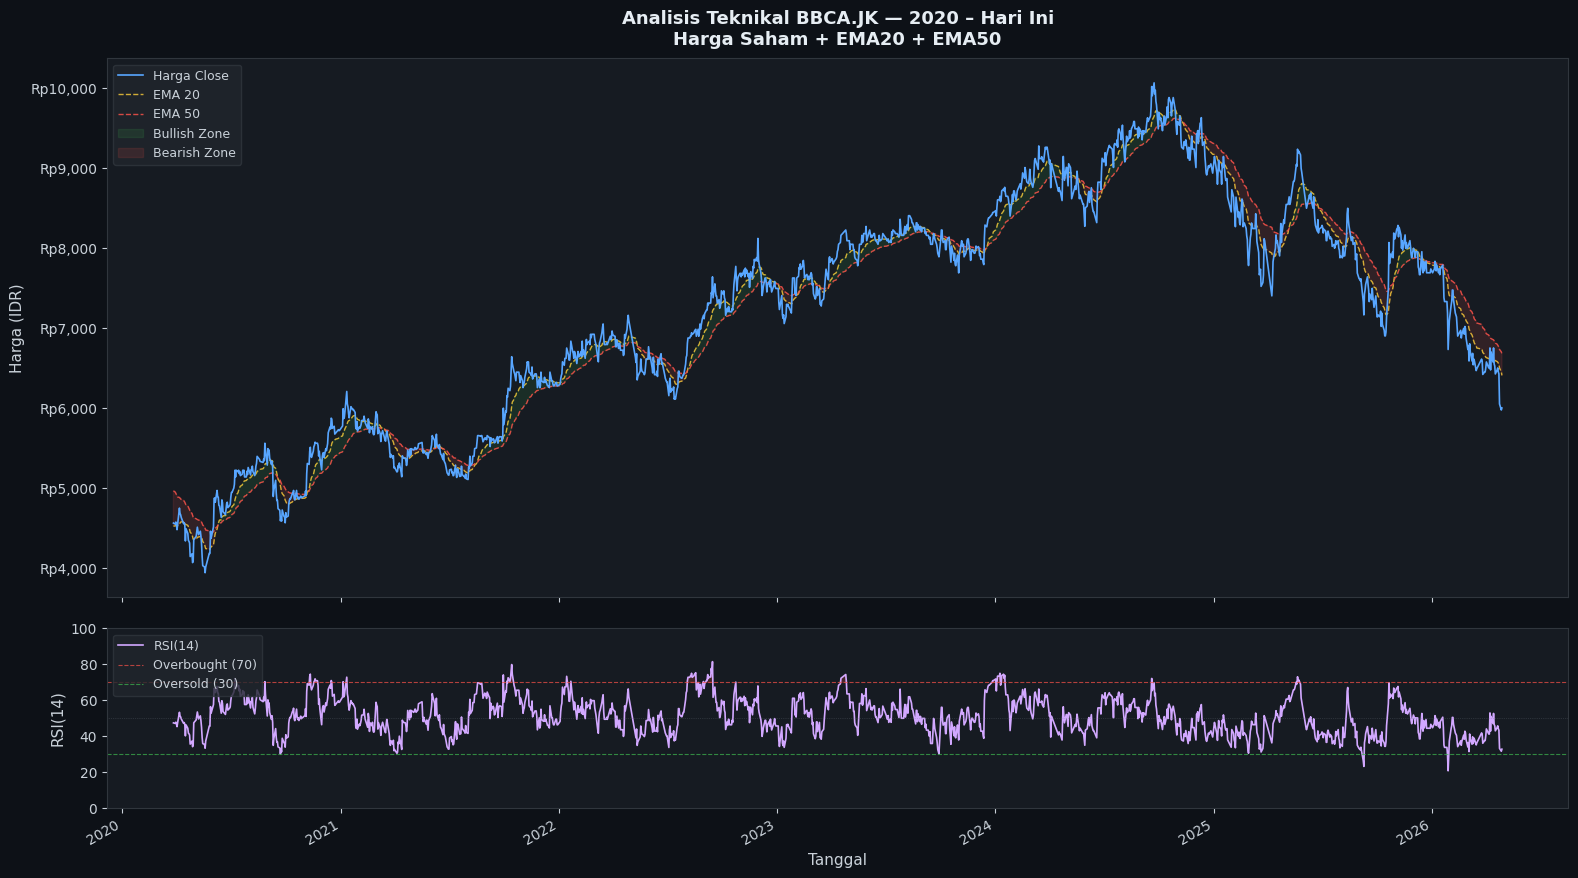

💾 Visualisasi 1 disimpan: viz1_technical_indicators.png


In [20]:
def plot_technical_indicators(df: pd.DataFrame, title_suffix: str = "Full Dataset"):
    """
    Membuat grafik dua panel:
    - Panel atas : Harga Close + EMA Short + EMA Long
    - Panel bawah: RSI dengan garis level 30 (oversold) dan 70 (overbought)
    """
    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(16, 9),
        gridspec_kw={"height_ratios": [3, 1]},
        sharex=True
    )
    fig.patch.set_facecolor("#0d1117")
    for ax in [ax1, ax2]:
        ax.set_facecolor("#161b22")
        ax.tick_params(colors="#c9d1d9")
        ax.spines[["top","right","left","bottom"]].set_color("#30363d")

    ax1.plot(df.index, df["Close"],     color="#58a6ff", linewidth=1.2, label="Harga Close", zorder=3)
    ax1.plot(df.index, df["ema_short"], color="#f0c539", linewidth=1.0, linestyle="--",
             label=f"EMA {EMA_SHORT}", alpha=0.85)
    ax1.plot(df.index, df["ema_long"],  color="#f85149", linewidth=1.0, linestyle="--",
             label=f"EMA {EMA_LONG}",  alpha=0.85)

    ax1.fill_between(
        df.index, df["ema_short"], df["ema_long"],
        where=df["ema_short"] >= df["ema_long"],
        alpha=0.12, color="#3fb950", label="Bullish Zone"
    )
    ax1.fill_between(
        df.index, df["ema_short"], df["ema_long"],
        where=df["ema_short"] < df["ema_long"],
        alpha=0.12, color="#f85149", label="Bearish Zone"
    )
    ax1.set_ylabel("Harga (IDR)", color="#c9d1d9", fontsize=11)
    ax1.legend(loc="upper left", facecolor="#21262d", edgecolor="#30363d",
               labelcolor="#c9d1d9", fontsize=9)
    ax1.set_title(
        f"Analisis Teknikal BBCA.JK — {title_suffix}\nHarga Saham + EMA{EMA_SHORT} + EMA{EMA_LONG}",
        color="#e6edf3", fontsize=13, fontweight="bold", pad=10
    )
    ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"Rp{x:,.0f}"))

    ax2.plot(df.index, df["rsi"], color="#d2a8ff", linewidth=1.2, label=f"RSI({RSI_PERIOD})")
    ax2.axhline(70, color="#f85149", linewidth=0.8, linestyle="--", alpha=0.7, label="Overbought (70)")
    ax2.axhline(30, color="#3fb950", linewidth=0.8, linestyle="--", alpha=0.7, label="Oversold (30)")
    ax2.axhline(50, color="#6e7681", linewidth=0.5, linestyle=":", alpha=0.5)
    ax2.fill_between(df.index, df["rsi"], 70, where=df["rsi"] >= 70, alpha=0.2, color="#f85149")
    ax2.fill_between(df.index, df["rsi"], 30, where=df["rsi"] <= 30, alpha=0.2, color="#3fb950")
    ax2.set_ylim(0, 100)
    ax2.set_ylabel(f"RSI({RSI_PERIOD})", color="#c9d1d9", fontsize=11)
    ax2.set_xlabel("Tanggal", color="#c9d1d9", fontsize=11)
    ax2.legend(loc="upper left", facecolor="#21262d", edgecolor="#30363d",
               labelcolor="#c9d1d9", fontsize=9)

    plt.xticks(color="#c9d1d9", rotation=30, ha="right")
    plt.tight_layout(pad=1.5)
    plt.savefig("viz1_technical_indicators.png", dpi=150, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    plt.show()
    print("💾 Visualisasi 1 disimpan: viz1_technical_indicators.png")


plot_technical_indicators(df_featured, "2020 – Hari Ini")

**Cell 6: Definisi Custom Environment (Gymnasium)**

In [21]:
FEATURE_COLUMNS = [
    "Close", "Open", "High", "Low", "Volume",
    "rsi", "ema_short", "ema_long",
    "fibo_0", "fibo_236", "fibo_382", "fibo_500", "fibo_618", "fibo_100",
    "daily_return", "volatility", "vol_normalized"
]

N_FEATURES = len(FEATURE_COLUMNS) + 3
class TradingEnv(gym.Env):
    """
    Custom Gymnasium Environment untuk simulasi trading saham.

    Observation Space (State):
        - Harga & Volume OHLCV
        - Indikator Teknikal: RSI, EMA Short/Long, 6 level Fibonacci
        - Fitur turunan: daily return, volatilitas, volume normalisasi
        - Status portofolio: saldo tersisa (norm), jumlah saham (norm), unrealized PnL (norm)

    Action Space:
        - 0: HOLD  — tidak melakukan apa-apa
        - 1: BUY   — membeli N_LOTS lot saham
        - 2: SELL  — menjual semua saham yang dipegang

    Reward Function:
        - Reward positif: pertumbuhan nilai portofolio dibanding langkah sebelumnya
        - Penalty kecil untuk HOLD saat posisi sudah untung (mendorong profit taking)
        - Penalty untuk aksi tidak valid (beli saat tak ada saldo, jual saat tak punya saham)
    """

    metadata = {"render_modes": ["human"]}

    def __init__(self, df: pd.DataFrame, initial_balance: float = INITIAL_BALANCE):
        super(TradingEnv, self).__init__()

        self.df              = df.reset_index(drop=True)
        self.initial_balance = initial_balance
        self.n_steps         = len(df)

        self.action_space = spaces.Discrete(3)
        self.observation_space = spaces.Box(
            low  = -np.inf,
            high =  np.inf,
            shape= (N_FEATURES,),
            dtype= np.float32
        )

        self._price_scale  = self.df["Close"].mean()
        self._volume_scale = self.df["Volume"].mean()
        self.reset()

    def reset(self, seed=None, options=None):
        """Mengatur ulang environment ke kondisi awal untuk episode baru."""
        super().reset(seed=seed)

        self.current_step   = 0
        self.balance        = self.initial_balance
        self.shares_held    = 0
        self.total_shares_bought  = 0
        self.total_shares_sold    = 0
        self.cost_basis     = 0.0
        self.total_profit   = 0.0
        self.trade_history  = []
        self.portfolio_values = [self.initial_balance]

        return self._get_observation(), {}

    # -----------------------------------------------------------------------
    def _get_observation(self) -> np.ndarray:
        """
        Mengambil state saat ini sebagai vektor numerik yang dinormalisasi.
        Normalisasi penting agar neural network PPO dapat belajar lebih cepat.
        """
        row = self.df.iloc[self.current_step]

        features = []
        for col in FEATURE_COLUMNS:
            val = row[col]
            if col in ["Close","Open","High","Low",
                       "fibo_0","fibo_236","fibo_382","fibo_500","fibo_618","fibo_100",
                       "ema_short","ema_long"]:
                val /= self._price_scale
            elif col == "Volume":
                val /= (self._volume_scale + 1e-9)
            features.append(float(val))

        current_price = row["Close"]
        portfolio_val = self.balance + self.shares_held * current_price

        features.append(self.balance / self.initial_balance)
        features.append(self.shares_held * LOT_SIZE / 1000.0)        # norm: ribuan lembar
        unrealized_pnl = (current_price - self.cost_basis) * self.shares_held if self.shares_held > 0 else 0
        features.append(unrealized_pnl / (self.initial_balance + 1e-9))

        return np.array(features, dtype=np.float32)

    def _calculate_portfolio_value(self) -> float:
        """Menghitung total nilai portofolio: saldo tunai + nilai saham saat ini."""
        current_price = self.df.iloc[self.current_step]["Close"]
        return self.balance + self.shares_held * current_price


    def step(self, action: int):
        """
        Mengeksekusi satu langkah trading berdasarkan aksi dari agen PPO.
        Mengembalikan: (observation, reward, terminated, truncated, info)
        """
        current_price     = self.df.iloc[self.current_step]["Close"]
        prev_portfolio_val= self._calculate_portfolio_value()
        reward            = 0.0
        trade_executed    = False

        if action == 1:  # BUY
            shares_to_buy = N_LOTS * LOT_SIZE
            cost          = shares_to_buy * current_price * (1 + TRANSACTION_FEE)

            if self.balance >= cost:
                total_prev_value   = self.cost_basis * self.shares_held
                self.shares_held  += shares_to_buy
                self.balance      -= cost
                self.cost_basis    = (total_prev_value + shares_to_buy * current_price) / self.shares_held
                self.total_shares_bought += shares_to_buy
                trade_executed     = True
                self.trade_history.append({"step": self.current_step, "action": "BUY",
                                           "price": current_price, "shares": shares_to_buy})
            else:
                reward -= 0.01

        elif action == 2:
            if self.shares_held > 0:
                revenue             = self.shares_held * current_price * (1 - TRANSACTION_FEE)
                realized_profit     = revenue - (self.cost_basis * self.shares_held)
                self.total_profit  += realized_profit
                self.balance       += revenue
                self.total_shares_sold += self.shares_held
                self.shares_held    = 0
                self.cost_basis     = 0.0
                trade_executed      = True
                self.trade_history.append({"step": self.current_step, "action": "SELL",
                                           "price": current_price, "shares": self.shares_held})
            else:
                reward -= 0.01

        current_portfolio_val = self._calculate_portfolio_value()
        self.portfolio_values.append(current_portfolio_val)

        portfolio_change = (current_portfolio_val - prev_portfolio_val) / (self.initial_balance + 1e-9)
        reward += portfolio_change * 100

        if trade_executed:
            reward += 0.001

        self.current_step += 1
        terminated = self.current_step >= self.n_steps - 1
        truncated  = False

        info = {
            "portfolio_value"  : current_portfolio_val,
            "balance"          : self.balance,
            "shares_held"      : self.shares_held,
            "total_profit"     : self.total_profit,
            "current_price"    : current_price,
        }

        return self._get_observation(), reward, terminated, truncated, info

    def render(self, mode="human"):
        """Menampilkan status terkini environment (opsional)."""
        current_price = self.df.iloc[self.current_step]["Close"]
        portfolio_val = self._calculate_portfolio_value()
        print(
            f"Step: {self.current_step:4d} | "
            f"Harga: Rp{current_price:>10,.0f} | "
            f"Saldo: Rp{self.balance:>14,.0f} | "
            f"Saham: {self.shares_held:>6,} | "
            f"Portfolio: Rp{portfolio_val:>14,.0f}"
        )

# **Cell 7: Pengujian Custom Environment**

In [22]:
print("🧪 Menguji Custom Environment...")
test_env = TradingEnv(df_train)
obs, _ = test_env.reset()
print(f"   Observation shape : {obs.shape}  (harus {N_FEATURES},)")
print(f"   Action space      : {test_env.action_space}")
print(f"   Sample observation:\n   {obs[:8]}  ...")

for _ in range(5):
    action = test_env.action_space.sample()
    obs, reward, done, _, info = test_env.step(action)

print(f"\n   Portfolio value setelah 5 langkah acak: Rp{info['portfolio_value']:,.0f}")
print("✅ Custom Environment berfungsi dengan baik.")

🧪 Menguji Custom Environment...
   Observation shape : (20,)  (harus 20,)
   Action space      : Discrete(3)
   Sample observation:
   [ 0.6460303   0.6284433   0.69117033  0.627857    3.109023   47.402107
  0.64062357  0.70302886]  ...

   Portfolio value setelah 5 langkah acak: Rp99,953,620
✅ Custom Environment berfungsi dengan baik.


# **Cell 8: Inisialisasi Callback & Setup MLflow**

In [23]:
class EpisodeRewardCallback(BaseCallback):
    """
    Callback untuk SB3 yang merekam total reward setiap episode.
    Menyimpan data reward untuk divisualisasikan sebagai learning curve.
    """

    def __init__(self, verbose: int = 0):
        super().__init__(verbose)
        self.episode_rewards  = []
        self.episode_lengths  = []
        self._current_episode_reward = 0.0
        self._current_episode_length = 0

    def _on_step(self) -> bool:
        self._current_episode_reward += float(self.locals["rewards"][0])
        self._current_episode_length += 1

        if self.locals["dones"][0]:
            self.episode_rewards.append(self._current_episode_reward)
            self.episode_lengths.append(self._current_episode_length)
            self._current_episode_reward = 0.0
            self._current_episode_length = 0

        return True


print("✅ Callback monitoring siap digunakan.")

os.makedirs("models", exist_ok=True)
os.makedirs("mlruns", exist_ok=True)

# Setup MLflow
mlflow.set_experiment(MLFLOW_EXPERIMENT)
print(f"📊 MLflow Experiment: '{MLFLOW_EXPERIMENT}'")
train_env = Monitor(TradingEnv(df_train))
reward_callback = EpisodeRewardCallback(verbose=0)

✅ Callback monitoring siap digunakan.


2026/05/01 16:30:08 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/01 16:30:09 INFO mlflow.store.db.utils: Updating database tables
2026/05/01 16:30:14 INFO mlflow.tracking.fluent: Experiment with name 'PPO_Trading_BBCA' does not exist. Creating a new experiment.


📊 MLflow Experiment: 'PPO_Trading_BBCA'


# **Cell 9: Training PPO & Logging MLflow**

In [24]:
print("\n🚀 Memulai Training PPO Agent...")
print("=" * 60)

with mlflow.start_run(run_name="PPO_BBCA_DRL_Run") as run:

    mlflow.log_params({
        "algorithm"       : "PPO",
        "total_timesteps" : TOTAL_TIMESTEPS,
        "initial_balance" : INITIAL_BALANCE,
        "train_ratio"     : TRAIN_RATIO,
        "rsi_period"      : RSI_PERIOD,
        "ema_short"       : EMA_SHORT,
        "ema_long"        : EMA_LONG,
        "fibo_lookback"   : FIBO_LOOKBACK,
        "n_lots"          : N_LOTS,
        "transaction_fee" : TRANSACTION_FEE,
        **PPO_PARAMS
    })
    print("📝 Parameters berhasil di-log ke MLflow.")

    model = PPO(
        policy          = "MlpPolicy",
        env             = train_env,
        learning_rate   = PPO_PARAMS["learning_rate"],
        n_steps         = PPO_PARAMS["n_steps"],
        batch_size      = PPO_PARAMS["batch_size"],
        n_epochs        = PPO_PARAMS["n_epochs"],
        gamma           = PPO_PARAMS["gamma"],
        gae_lambda      = PPO_PARAMS["gae_lambda"],
        clip_range      = PPO_PARAMS["clip_range"],
        ent_coef        = PPO_PARAMS["ent_coef"],
        verbose         = PPO_PARAMS["verbose"],
        tensorboard_log = "./tb_logs/",
    )

    print(f"\n🧠 Model PPO diinisialisasi.")
    print(f"   Policy Network: MlpPolicy (MLP dengan hidden layers)")
    print(f"   Observation Dim: {train_env.observation_space.shape[0]}")
    print(f"   Action Dim     : {train_env.action_space.n}")
    print(f"\n⏳ Training sedang berjalan... ({TOTAL_TIMESTEPS:,} timesteps)")

    model.learn(
        total_timesteps = TOTAL_TIMESTEPS,
        callback        = reward_callback,
        progress_bar    = True
    )

    print(f"\n✅ Training selesai!")
    print(f"   Total episode    : {len(reward_callback.episode_rewards)}")
    print(f"   Avg reward 10 ep terakhir: {np.mean(reward_callback.episode_rewards[-10:]):.4f}")

    model_path = f"models/{MODEL_SAVE_PATH}"
    model.save(model_path)
    print(f"\n💾 Model disimpan ke: {model_path}.zip")

    mlflow.log_artifact(f"{model_path}.zip", artifact_path="model")
    mlflow.log_artifact("viz1_technical_indicators.png", artifact_path="visualizations")
    print("📦 Model artifact berhasil di-upload ke MLflow.")

    run_id = run.info.run_id
    print(f"\n🔖 MLflow Run ID: {run_id}")

print("\n✅ Tahap Training & MLflow Logging selesai.")


🚀 Memulai Training PPO Agent...
📝 Parameters berhasil di-log ke MLflow.


Output()


🧠 Model PPO diinisialisasi.
   Policy Network: MlpPolicy (MLP dengan hidden layers)
   Observation Dim: 20
   Action Dim     : 3

⏳ Training sedang berjalan... (200,000 timesteps)



✅ Training selesai!
   Total episode    : 171
   Avg reward 10 ep terakhir: -0.0036

💾 Model disimpan ke: models/ppo_bbca_model.zip
📦 Model artifact berhasil di-upload ke MLflow.

🔖 MLflow Run ID: 8ee190bbae2146b3aa1026c82b695b86

✅ Tahap Training & MLflow Logging selesai.


# **Cell 10: Visualisasi Kurva Belajar (Learning Curve)**

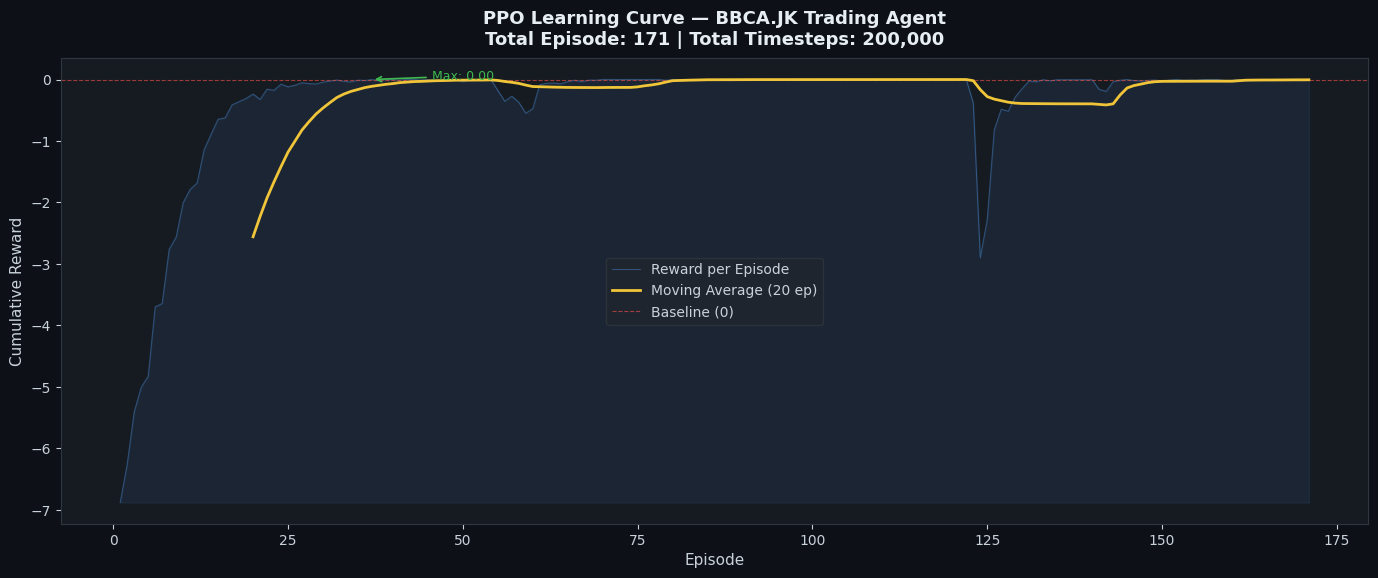

💾 Visualisasi 2 disimpan: viz2_learning_curve.png


In [25]:
def plot_learning_curve(episode_rewards: list, window: int = 20):
    """
    Membuat plot Learning Curve dari cumulative reward per episode.
    Menampilkan raw reward dan moving average untuk melihat tren umum.
    """
    fig, ax = plt.subplots(figsize=(14, 6))
    fig.patch.set_facecolor("#0d1117")
    ax.set_facecolor("#161b22")
    ax.tick_params(colors="#c9d1d9")
    ax.spines[["top","right","left","bottom"]].set_color("#30363d")

    episodes = range(1, len(episode_rewards) + 1)
    rewards  = np.array(episode_rewards)
    ax.plot(episodes, rewards, color="#58a6ff", alpha=0.35, linewidth=0.8, label="Reward per Episode")

    if len(rewards) >= window:
        ma = pd.Series(rewards).rolling(window=window).mean()
        ax.plot(episodes, ma, color="#f0c539", linewidth=2.0,
                label=f"Moving Average ({window} ep)", zorder=3)

    ax.fill_between(episodes, rewards.min(), rewards, alpha=0.08, color="#58a6ff")
    ax.axhline(0, color="#f85149", linewidth=0.8, linestyle="--", alpha=0.6, label="Baseline (0)")
    ax.set_title(
        f"PPO Learning Curve — BBCA.JK Trading Agent\n"
        f"Total Episode: {len(episodes)} | Total Timesteps: {TOTAL_TIMESTEPS:,}",
        color="#e6edf3", fontsize=13, fontweight="bold", pad=10
    )
    ax.set_xlabel("Episode", color="#c9d1d9", fontsize=11)
    ax.set_ylabel("Cumulative Reward", color="#c9d1d9", fontsize=11)
    ax.legend(facecolor="#21262d", edgecolor="#30363d", labelcolor="#c9d1d9", fontsize=10)

    max_idx = np.argmax(rewards)
    ax.annotate(
        f"Max: {rewards[max_idx]:.2f}",
        xy=(max_idx + 1, rewards[max_idx]),
        xytext=(max_idx + 1 + len(episodes)*0.05, rewards[max_idx]),
        color="#3fb950", fontsize=9,
        arrowprops=dict(arrowstyle="->", color="#3fb950", lw=1.2)
    )

    plt.tight_layout(pad=1.5)
    plt.savefig("viz2_learning_curve.png", dpi=150, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    plt.show()
    print(" Visualisasi 2 disimpan: viz2_learning_curve.png")


plot_learning_curve(reward_callback.episode_rewards)

with mlflow.start_run(run_id=run_id):
    mlflow.log_artifact("viz2_learning_curve.png", artifact_path="visualizations")

# **Cell 11: Backtesting Agent pada Data Test**

In [26]:
print(" Memuat model PPO yang sudah dilatih...")
model_loaded = PPO.load(f"models/{MODEL_SAVE_PATH}")
print(f"   Model berhasil dimuat dari: models/{MODEL_SAVE_PATH}.zip")

test_env_bt = TradingEnv(df_test)
obs, _ = test_env_bt.reset()

backtest_results = {
    "steps"           : [],
    "dates"           : [],
    "prices"          : [],
    "actions"         : [],
    "portfolio_values": [],
    "balances"        : [],
    "shares_held"     : [],
}

print(f"\n Menjalankan Backtesting pada {len(df_test)} hari data test...")
print("-" * 60)

done = False
step_count = 0

while not done:
    action, _ = model_loaded.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = test_env_bt.step(action)
    done = terminated or truncated

    # Simpan data langkah ini
    backtest_results["steps"].append(step_count)
    backtest_results["dates"].append(df_test.index[step_count])
    backtest_results["prices"].append(info["current_price"])
    backtest_results["actions"].append(int(action))
    backtest_results["portfolio_values"].append(info["portfolio_value"])
    backtest_results["balances"].append(info["balance"])
    backtest_results["shares_held"].append(info["shares_held"])

    step_count += 1

bt_df = pd.DataFrame(backtest_results)
bt_df.set_index("dates", inplace=True)

final_portfolio    = bt_df["portfolio_values"].iloc[-1]
total_profit_pct   = (final_portfolio - INITIAL_BALANCE) / INITIAL_BALANCE * 100

buy_signals  = bt_df[bt_df["actions"] == 1]
sell_signals = bt_df[bt_df["actions"] == 2]
hold_signals = bt_df[bt_df["actions"] == 0]

total_trades = len(buy_signals) + len(sell_signals)

daily_returns_bt = bt_df["portfolio_values"].pct_change().dropna()
win_rate         = (daily_returns_bt > 0).sum() / len(daily_returns_bt) * 100

risk_free_daily = 0.05 / 252
excess_returns  = daily_returns_bt - risk_free_daily
sharpe_ratio    = (excess_returns.mean() / (excess_returns.std() + 1e-9)) * np.sqrt(252)

rolling_max  = bt_df["portfolio_values"].cummax()
drawdown     = (bt_df["portfolio_values"] - rolling_max) / rolling_max
max_drawdown = drawdown.min() * 100

print("\n" + "=" * 60)
print(" HASIL BACKTESTING — EVALUASI AKHIR")
print("=" * 60)
print(f"   Modal Awal            : Rp {INITIAL_BALANCE:>15,.0f}")
print(f"   Nilai Akhir Portofolio: Rp {final_portfolio:>15,.0f}")
print(f"   Total Profit/Loss     : Rp {final_portfolio - INITIAL_BALANCE:>+15,.0f}  ({total_profit_pct:+.2f}%)")
print(f"   Sharpe Ratio          : {sharpe_ratio:.4f}")
print(f"   Win Rate              : {win_rate:.2f}%")
print(f"   Maximum Drawdown      : {max_drawdown:.2f}%")
print(f"   Total Transaksi       : {total_trades} (Buy: {len(buy_signals)}, Sell: {len(sell_signals)})")
print(f"   Total Hari HOLD       : {len(hold_signals)}")
print("=" * 60)

with mlflow.start_run(run_id=run_id):
    mlflow.log_metrics({
        "total_profit_pct" : round(total_profit_pct, 4),
        "final_portfolio"  : round(final_portfolio, 2),
        "sharpe_ratio"     : round(sharpe_ratio, 4),
        "win_rate_pct"     : round(win_rate, 4),
        "max_drawdown_pct" : round(max_drawdown, 4),
        "total_trades"     : total_trades,
        "buy_signals"      : len(buy_signals),
        "sell_signals"     : len(sell_signals),
    })
    print("\n Metrik evaluasi berhasil di-log ke MLflow.")

🔄 Memuat model PPO yang sudah dilatih...
   Model berhasil dimuat dari: models/ppo_bbca_model.zip

📈 Menjalankan Backtesting pada 293 hari data test...
------------------------------------------------------------

📊 HASIL BACKTESTING — EVALUASI AKHIR
   Modal Awal            : Rp     100,000,000
   Nilai Akhir Portofolio: Rp     100,000,000
   Total Profit/Loss     : Rp              +0  (+0.00%)
   Sharpe Ratio          : -3149703.9399
   Win Rate              : 0.00%
   Maximum Drawdown      : 0.00%
   Total Transaksi       : 0 (Buy: 0, Sell: 0)
   Total Hari HOLD       : 292

📝 Metrik evaluasi berhasil di-log ke MLflow.


# **Cell 12: Visualisasi Sinyal Trading (Plotly Interaktif)**

In [27]:
def plot_trading_signals_interactive(bt_df: pd.DataFrame, df_test: pd.DataFrame):
    """
    Membuat grafik interaktif Plotly dengan:
    - Garis harga Close + EMA dari data test
    - Marker ▲ hijau untuk sinyal BUY
    - Marker ▼ merah untuk sinyal SELL
    """
    buy_mask  = bt_df["actions"] == 1
    sell_mask = bt_df["actions"] == 2

    fig = make_subplots(
        rows=2, cols=1,
        shared_xaxes=True,
        vertical_spacing=0.08,
        row_heights=[0.72, 0.28],
        subplot_titles=[
            "Harga Saham BBCA.JK + Sinyal Trading (Data Test)",
            f"RSI ({RSI_PERIOD})"
        ]
    )

    fig.add_trace(
        go.Candlestick(
            x     = df_test.index,
            open  = df_test["Open"],
            high  = df_test["High"],
            low   = df_test["Low"],
            close = df_test["Close"],
            name  = "Candlestick",
            increasing_line_color = "#3fb950",
            decreasing_line_color = "#f85149",
            showlegend = True,
        ),
        row=1, col=1
    )

    fig.add_trace(
        go.Scatter(
            x=df_test.index, y=df_test["ema_short"],
            name=f"EMA {EMA_SHORT}", line=dict(color="#f0c539", width=1.2, dash="dot"),
            opacity=0.85
        ),
        row=1, col=1
    )

    fig.add_trace(
        go.Scatter(
            x=df_test.index, y=df_test["ema_long"],
            name=f"EMA {EMA_LONG}", line=dict(color="#d2a8ff", width=1.2, dash="dot"),
            opacity=0.85
        ),
        row=1, col=1
    )

    if buy_mask.any():
        fig.add_trace(
            go.Scatter(
                x    = bt_df.index[buy_mask],
                y    = bt_df["prices"][buy_mask] * 0.985,    # Sedikit di bawah harga
                name = "BUY Signal",
                mode = "markers",
                marker=dict(
                    symbol = "triangle-up",
                    size   = 12,
                    color  = "#3fb950",
                    line   = dict(color="#ffffff", width=0.5)
                ),
                hovertemplate = "<b>BUY</b><br>Tanggal: %{x}<br>Harga: Rp%{y:,.0f}<extra></extra>"
            ),
            row=1, col=1
        )

    if sell_mask.any():
        fig.add_trace(
            go.Scatter(
                x    = bt_df.index[sell_mask],
                y    = bt_df["prices"][sell_mask] * 1.015,   # Sedikit di atas harga
                name = "SELL Signal",
                mode = "markers",
                marker=dict(
                    symbol = "triangle-down",
                    size   = 12,
                    color  = "#f85149",
                    line   = dict(color="#ffffff", width=0.5)
                ),
                hovertemplate = "<b>SELL</b><br>Tanggal: %{x}<br>Harga: Rp%{y:,.0f}<extra></extra>"
            ),
            row=1, col=1
        )

    fig.add_trace(
        go.Scatter(
            x=df_test.index, y=df_test["rsi"],
            name=f"RSI ({RSI_PERIOD})",
            line=dict(color="#58a6ff", width=1.2),
            fill="tozeroy",
            fillcolor="rgba(88,166,255,0.08)"
        ),
        row=2, col=1
    )
    # Level overbought & oversold
    for level, color, label in [(70, "#f85149", "Overbought"), (30, "#3fb950", "Oversold")]:
        fig.add_hline(
            y=level, line_dash="dash", line_color=color,
            line_width=0.8, opacity=0.7, row=2, col=1,
            annotation_text=label, annotation_position="right"
        )

    # --- Layout ---
    fig.update_layout(
        title=dict(
            text = f"<b>PPO Trading Agent — Backtesting BBCA.JK</b><br>"
                   f"<sup>Profit: {total_profit_pct:+.2f}% | Sharpe: {sharpe_ratio:.3f} | "
                   f"Win Rate: {win_rate:.1f}% | MDD: {max_drawdown:.2f}%</sup>",
            font = dict(size=16, color="#e6edf3"),
            x    = 0.5
        ),
        template     = "plotly_dark",
        paper_bgcolor= "#0d1117",
        plot_bgcolor = "#161b22",
        height       = 700,
        xaxis_rangeslider_visible = False,
        legend=dict(
            orientation = "h",
            yanchor     = "bottom",
            y           = 1.01,
            xanchor     = "right",
            x           = 1,
            font        = dict(size=10)
        ),
        hovermode    = "x unified",
        margin       = dict(l=60, r=60, t=100, b=60)
    )
    fig.update_yaxes(title_text="Harga (IDR)", row=1, col=1)
    fig.update_yaxes(title_text="RSI", range=[0, 100], row=2, col=1)

    fig.write_html("viz3_trading_signals.html")
    fig.show()
    print("💾 Visualisasi 3 disimpan: viz3_trading_signals.html")


plot_trading_signals_interactive(bt_df, df_test)


with mlflow.start_run(run_id=run_id):
    mlflow.log_artifact("viz3_trading_signals.html", artifact_path="visualizations")

💾 Visualisasi 3 disimpan: viz3_trading_signals.html


# **Cell 13: Visualisasi Pertumbuhan Portofolio**

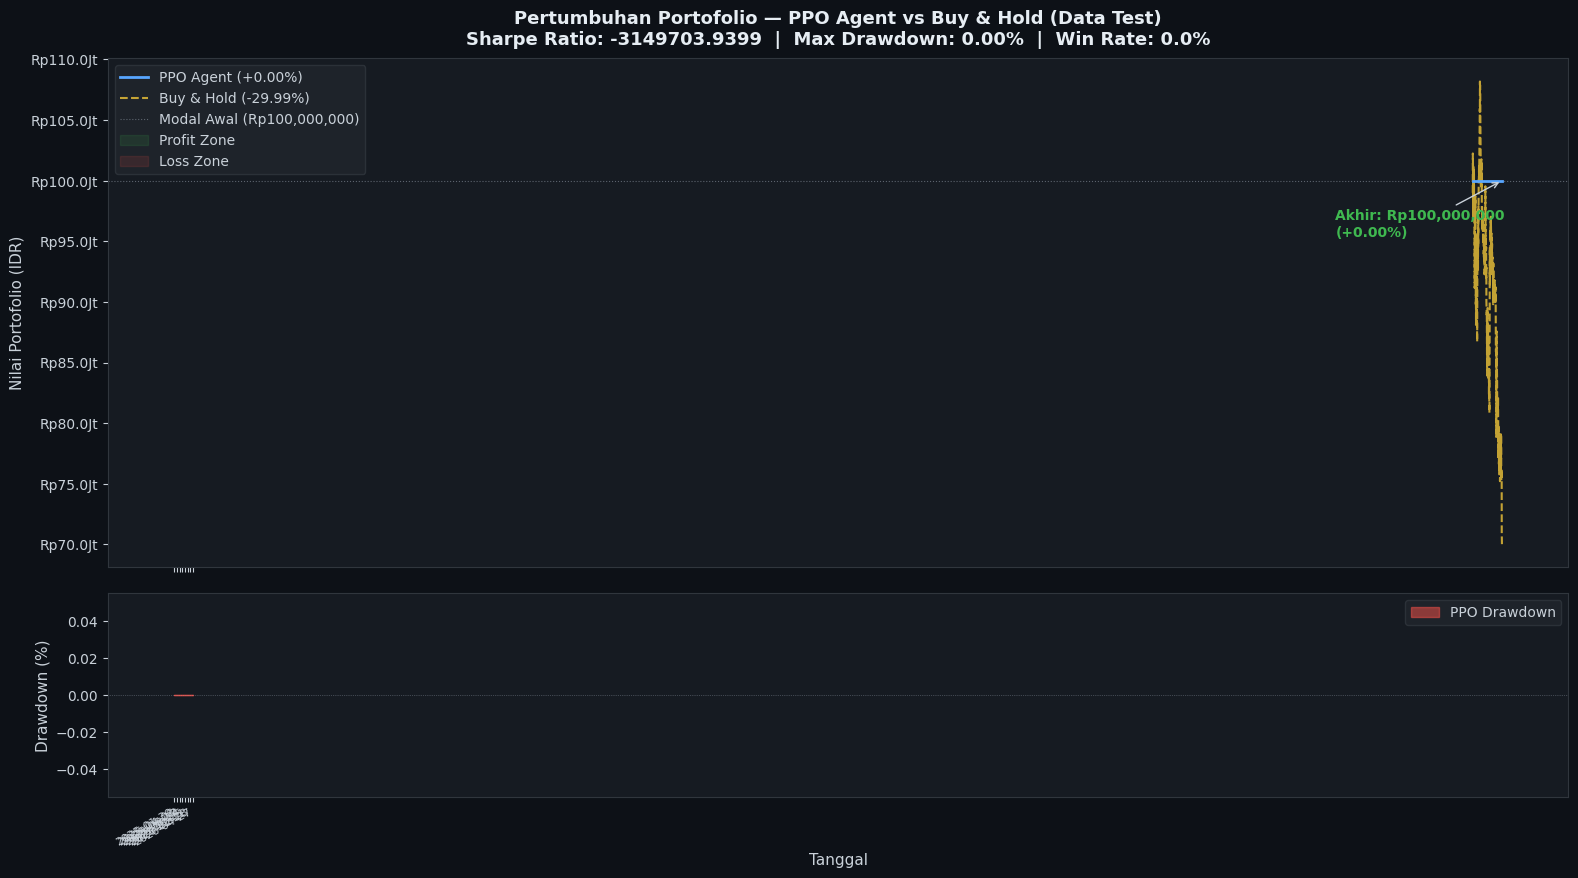

💾 Visualisasi 4 disimpan: viz4_portfolio_growth.png


In [28]:
def plot_portfolio_growth(bt_df: pd.DataFrame, df_test: pd.DataFrame,
                           initial_balance: float = INITIAL_BALANCE):
    """
    Membuat grafik pertumbuhan nilai portofolio:
    - Nilai portofolio agen PPO dari waktu ke waktu
    - Perbandingan dengan strategi Buy & Hold (benchmark)
    - Drawdown (penurunan dari titik tertinggi)
    """
    # Hitung strategi benchmark Buy & Hold
    bh_initial_shares  = (initial_balance * 0.99) / df_test["Close"].iloc[0]  # Beli di hari pertama
    bh_portfolio        = bh_initial_shares * df_test["Close"]

    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(16, 9),
        gridspec_kw={"height_ratios": [2.5, 1]},
        sharex=True
    )
    fig.patch.set_facecolor("#0d1117")
    for ax in [ax1, ax2]:
        ax.set_facecolor("#161b22")
        ax.tick_params(colors="#c9d1d9")
        ax.spines[["top","right","left","bottom"]].set_color("#30363d")

    # --- Panel 1: Pertumbuhan Portofolio ---
    ppo_values = bt_df["portfolio_values"].values
    bh_values  = bh_portfolio.values[:len(ppo_values)]
    dates      = bt_df.index

    ax1.plot(dates, ppo_values, color="#58a6ff", linewidth=2.0,
             label=f"PPO Agent ({total_profit_pct:+.2f}%)", zorder=3)
    ax1.plot(dates, bh_values,  color="#f0c539", linewidth=1.5, linestyle="--",
             label=f"Buy & Hold ({(bh_values[-1]/initial_balance-1)*100:+.2f}%)", alpha=0.8)

    # Garis modal awal
    ax1.axhline(initial_balance, color="#6e7681", linewidth=0.8, linestyle=":",
                alpha=0.8, label=f"Modal Awal (Rp{initial_balance:,.0f})")

    # Shading: area di atas modal = profit (hijau), di bawah = rugi (merah)
    ax1.fill_between(dates, initial_balance, ppo_values,
                     where=np.array(ppo_values) >= initial_balance,
                     alpha=0.12, color="#3fb950", label="Profit Zone")
    ax1.fill_between(dates, initial_balance, ppo_values,
                     where=np.array(ppo_values) < initial_balance,
                     alpha=0.12, color="#f85149", label="Loss Zone")

    # Anotasi nilai akhir
    ax1.annotate(
        f"Akhir: Rp{ppo_values[-1]:,.0f}\n({total_profit_pct:+.2f}%)",
        xy=(dates[-1], ppo_values[-1]),
        xytext=(-120, -40), textcoords="offset points",
        color="#3fb950" if ppo_values[-1] >= initial_balance else "#f85149",
        fontsize=10, fontweight="bold",
        arrowprops=dict(arrowstyle="->", color="#c9d1d9", lw=1.0)
    )

    ax1.set_ylabel("Nilai Portofolio (IDR)", color="#c9d1d9", fontsize=11)
    ax1.set_title(
        f"Pertumbuhan Portofolio — PPO Agent vs Buy & Hold (Data Test)\n"
        f"Sharpe Ratio: {sharpe_ratio:.4f}  |  Max Drawdown: {max_drawdown:.2f}%  |  "
        f"Win Rate: {win_rate:.1f}%",
        color="#e6edf3", fontsize=13, fontweight="bold", pad=10
    )
    ax1.legend(loc="upper left", facecolor="#21262d", edgecolor="#30363d",
               labelcolor="#c9d1d9", fontsize=10)
    ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"Rp{x/1e6:.1f}Jt"))

    # --- Panel 2: Drawdown ---
    rolling_max_ppo = pd.Series(ppo_values).cummax()
    drawdown_ppo    = (pd.Series(ppo_values) - rolling_max_ppo) / rolling_max_ppo * 100

    ax2.fill_between(range(len(dates)), 0, drawdown_ppo.values,
                     color="#f85149", alpha=0.5, label="PPO Drawdown")
    ax2.plot(range(len(dates)), drawdown_ppo.values, color="#f85149", linewidth=0.8)
    ax2.axhline(0, color="#6e7681", linewidth=0.5, linestyle=":")

    ax2.set_ylabel("Drawdown (%)", color="#c9d1d9", fontsize=11)
    ax2.set_xlabel("Tanggal", color="#c9d1d9", fontsize=11)
    ax2.legend(facecolor="#21262d", edgecolor="#30363d", labelcolor="#c9d1d9", fontsize=10)

    # Konversi x-ticks kembali ke tanggal
    tick_positions = np.linspace(0, len(dates)-1, 8, dtype=int)
    ax2.set_xticks(tick_positions)
    ax2.set_xticklabels([str(dates[i].date()) for i in tick_positions],
                         rotation=30, ha="right", color="#c9d1d9", fontsize=8)

    plt.tight_layout(pad=1.5)
    plt.savefig("viz4_portfolio_growth.png", dpi=150, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    plt.show()
    print("💾 Visualisasi 4 disimpan: viz4_portfolio_growth.png")


plot_portfolio_growth(bt_df, df_test, INITIAL_BALANCE)

# Log ke MLflow
with mlflow.start_run(run_id=run_id):
    mlflow.log_artifact("viz4_portfolio_growth.png", artifact_path="visualizations")

# **Cell 14: Ringkasan Akhir & MLflow UI**

In [30]:

print("\n" + "=" * 65)
print("    RINGKASAN AKHIR EKSPERIMEN MLOps")
print("=" * 65)
print(f"\n  Experiment  : {MLFLOW_EXPERIMENT}")
print(f"  Run ID      : {run_id}")
print(f"\n  ── Konfigurasi ──────────────────────────────────────────")
print(f"  Algoritma         : PPO (Proximal Policy Optimization)")
print(f"  Total Timesteps   : {TOTAL_TIMESTEPS:,}")
print(f"  Learning Rate     : {PPO_PARAMS['learning_rate']}")
print(f"  Batch Size        : {PPO_PARAMS['batch_size']}")
print(f"\n  ── Hasil Backtesting ────────────────────────────────────")
print(f"  Modal Awal        : Rp {INITIAL_BALANCE:,.0f}")
print(f"  Nilai Akhir       : Rp {bt_df['portfolio_values'].iloc[-1]:,.0f}")
print(f"  Total Return      : {total_profit_pct:+.2f}%")
print(f"  Sharpe Ratio      : {sharpe_ratio:.4f}")
print(f"  Win Rate          : {win_rate:.2f}%")
print(f"  Max Drawdown      : {max_drawdown:.2f}%")
print(f"  Total Transaksi   : {total_trades}")
print(f"\n  ── Artifacts Tersimpan ──────────────────────────────────")
print(f"   viz1_technical_indicators.png  — Harga + EMA + RSI")
print(f"   viz2_learning_curve.png        — Kurva Belajar PPO")
print(f"    viz3_trading_signals.html      — Sinyal BUY/SELL interaktif")
print(f"   viz4_portfolio_growth.png      — Pertumbuhan Portofolio")
print(f"   models/{MODEL_SAVE_PATH}.zip       — Model PPO terlatih")



    RINGKASAN AKHIR EKSPERIMEN MLOps

  Experiment  : PPO_Trading_BBCA
  Run ID      : 8ee190bbae2146b3aa1026c82b695b86

  ── Konfigurasi ──────────────────────────────────────────
  Algoritma         : PPO (Proximal Policy Optimization)
  Total Timesteps   : 200,000
  Learning Rate     : 0.0003
  Batch Size        : 64

  ── Hasil Backtesting ────────────────────────────────────
  Modal Awal        : Rp 100,000,000
  Nilai Akhir       : Rp 100,000,000
  Total Return      : +0.00%
  Sharpe Ratio      : -3149703.9399
  Win Rate          : 0.00%
  Max Drawdown      : 0.00%
  Total Transaksi   : 0

  ── Artifacts Tersimpan ──────────────────────────────────
   viz1_technical_indicators.png  — Harga + EMA + RSI
   viz2_learning_curve.png        — Kurva Belajar PPO
    viz3_trading_signals.html      — Sinyal BUY/SELL interaktif
   viz4_portfolio_growth.png      — Pertumbuhan Portofolio
   models/ppo_bbca_model.zip       — Model PPO terlatih
